In [1]:
# just one time run this cell
import sys
import os
sys.path.append(os.path.abspath('../'))

In [2]:
from src.genetic import genetic_coloring,plot_colored_graph
import matplotlib.pyplot as plt
import numpy as np

In [3]:
max_generations=300
solfitness = 62.5

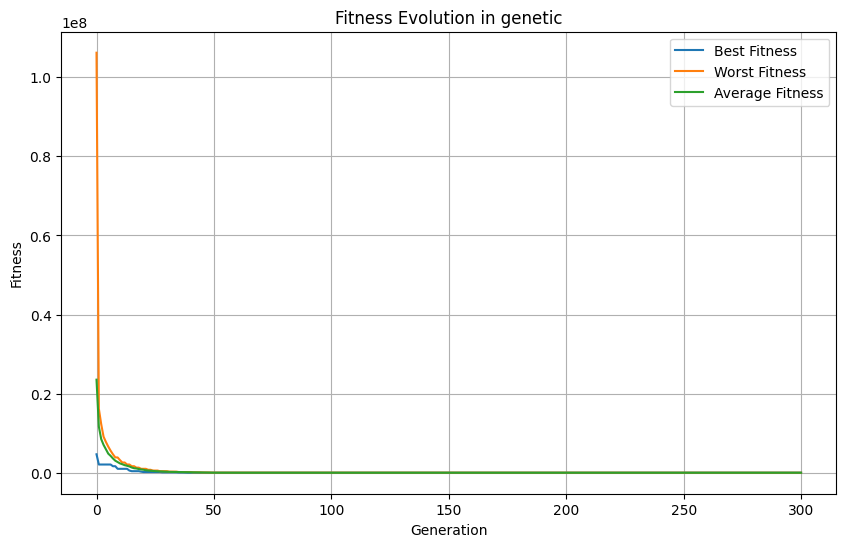

Best Solution :	 [4 1 0 3 2 3 2 4 4 1 1 0 1 2 4 2 3 4 0 0 0 4 2 1 3] 
		Generation : 	 39 
		Fitness : 	 25982.5


In [4]:
file_path = "../data/queen5_5.col"

best_fitness_values, worst_fitness_values, avg_fitness_values, best_sol, best_gen,G = genetic_coloring(file_path,100,5,0.9,0.1,max_generations,solfitness=solfitness)
plt.figure(figsize=(10, 6))
plt.plot(range(len(best_fitness_values)),best_fitness_values, label='Best Fitness')
plt.plot(range(len(best_fitness_values)),worst_fitness_values, label='Worst Fitness')
plt.plot(range(len(best_fitness_values)),avg_fitness_values, label='Average Fitness')
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.title('Fitness Evolution in genetic')
plt.legend()
plt.grid(True)
plt.show()
print("Best Solution :\t",best_sol,"\n\t\tGeneration : \t",best_gen,"\n\t\tFitness : \t",best_fitness_values[-1])

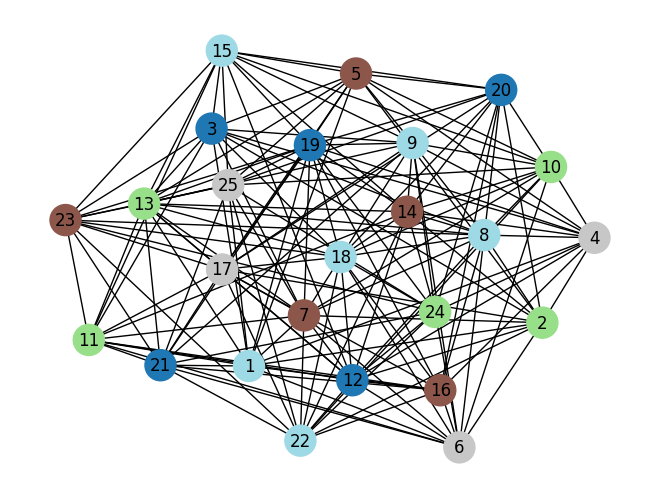

In [5]:
plot_colored_graph(G,best_sol)

In [6]:
num_runs=5

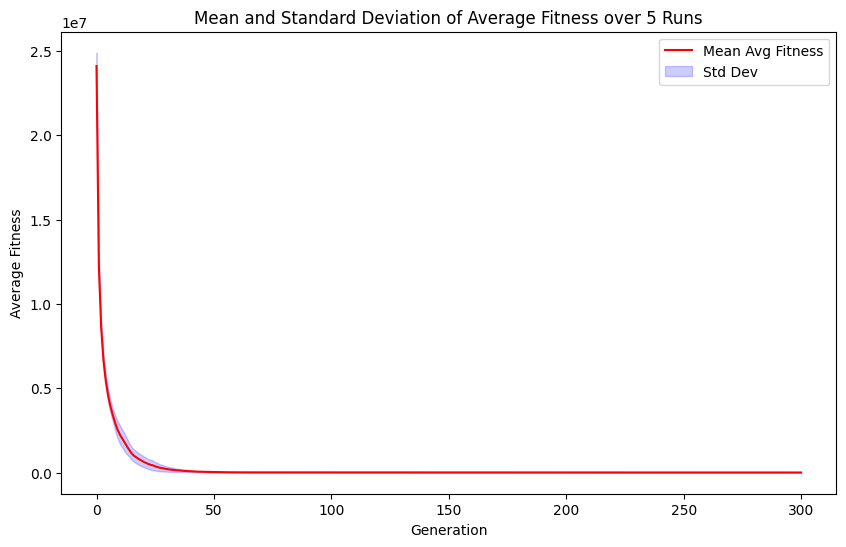

In [7]:
fitness_values = []
for _ in range(num_runs):
    _, _, avg_fitness_values, _, _,_ = genetic_coloring(file_path,100,5,0.9,0.1,max_generations)
    avg_fitness_values = np.pad(avg_fitness_values, (0, max_generations+1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
    fitness_values.append(avg_fitness_values)
fitness_values = np.array(fitness_values)
mean_avg_fitness = np.mean(fitness_values, axis=0)
std_avg_fitness = np.std(fitness_values, axis=0)
generations = np.arange(len(mean_avg_fitness))
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_avg_fitness, label='Mean Avg Fitness', color='red')
plt.fill_between(generations, mean_avg_fitness - std_avg_fitness, mean_avg_fitness + std_avg_fitness, color='b', alpha=0.2, label='Std Dev')
plt.xlabel('Generation')
plt.ylabel('Average Fitness')
plt.title('Mean and Standard Deviation of Average Fitness over 5 Runs')
plt.legend()
plt.show()


Problem size: 25
	Best fitness: 62.5
			Generation: 42
	Best fitness: 25982.5
			Generation: 116
	Best fitness: 25982.5
			Generation: 24
	Best fitness: 62.5
			Generation: 116
	Best fitness: 62.5
			Generation: 48
Avg last generation: 10430.5


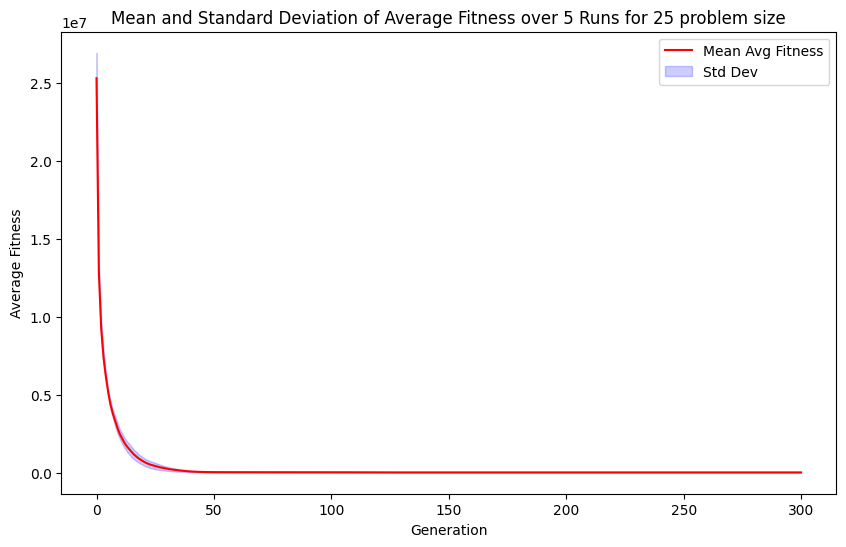

Problem size: 36
	Best fitness: 1860.1
			Generation: 110
	Best fitness: 1860.1
			Generation: 144
	Best fitness: 1860.1
			Generation: 284
	Best fitness: 560.1
			Generation: 282
	Best fitness: 1860.1
			Generation: 125
Avg last generation: 1882.3


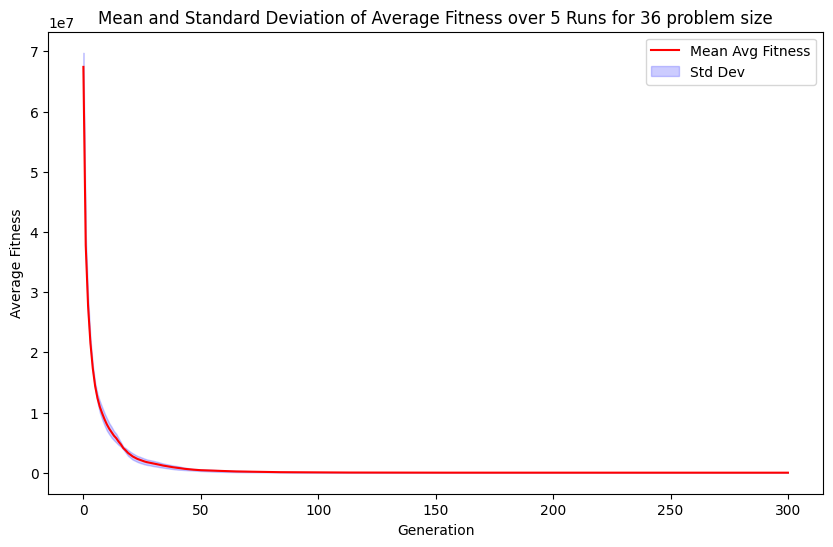

Problem size: 49
	Best fitness: 571460.1
			Generation: 238
	Best fitness: 571460.1
			Generation: 240
	Best fitness: 571460.1
			Generation: 204
	Best fitness: 293060.1
			Generation: 244
	Best fitness: 414960.1
			Generation: 298
Avg last generation: 745389.3399999996


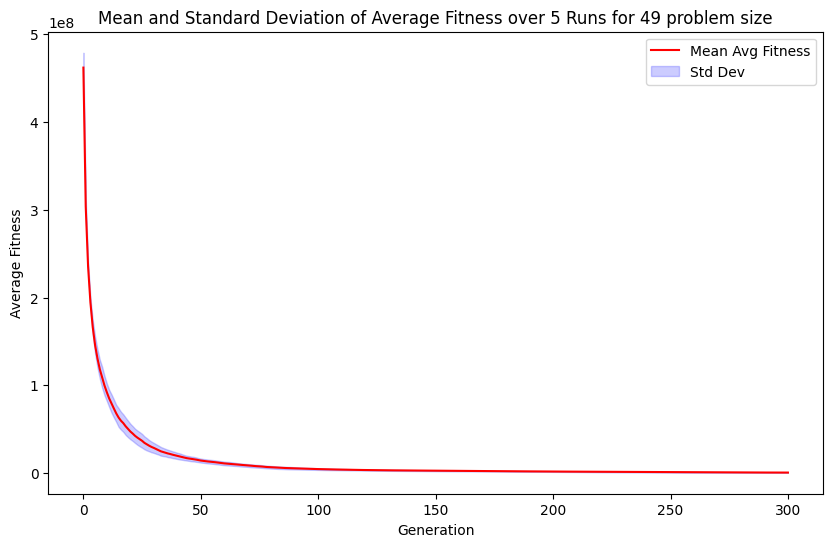

Problem size: 96
	Best fitness: 26728793.6
			Generation: 292
	Best fitness: 41704793.6
			Generation: 253
	Best fitness: 30014573.6
			Generation: 213
	Best fitness: 26728793.6
			Generation: 293
	Best fitness: 33594393.6
			Generation: 234
Avg last generation: 59941333.08000003


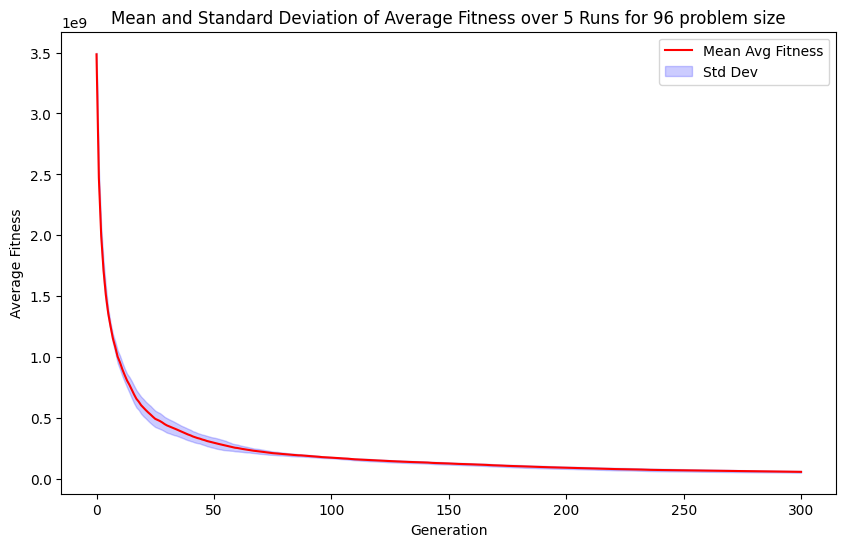

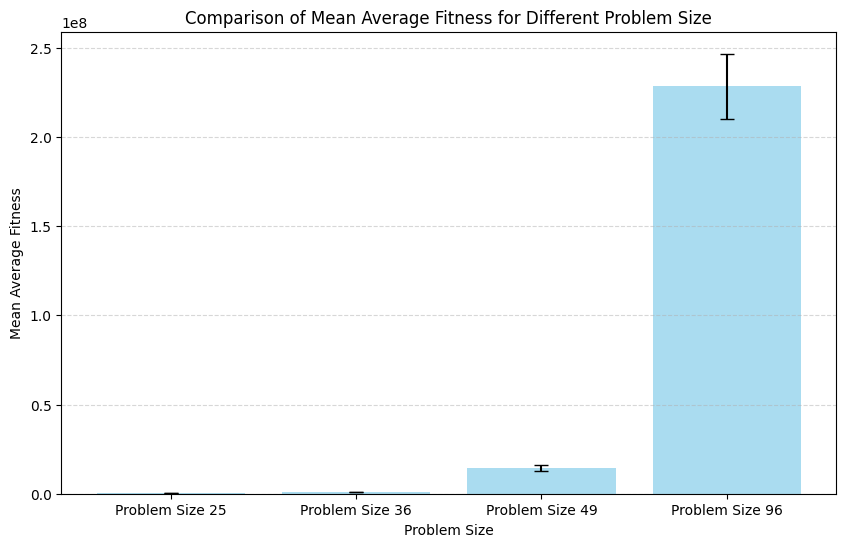

In [8]:
prob_file_paths = ["queen5_5.col","queen6_6.col","queen7_7.col","queen8_12.col"] 
probsize = [25,36,49,96]
colors = [5,7,7,12]
all_mean_avg_fitness = []
all_std_avg_fitness = []
for i in range(len(probsize)):
    print("Problem size:",probsize[i])
    fitness_values = []
    for _ in range(num_runs):
        bf, _, avg_fitness_values,_,bestgen,_ = genetic_coloring("../data/"+prob_file_paths[i],100,colors[i],0.9,0.1,max_generations)
        avg_fitness_values = np.pad(avg_fitness_values, (0, max_generations+ 1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
        fitness_values.append(avg_fitness_values)
        print("\tBest fitness:",bf[bestgen])
        print("\t\t\tGeneration:",bestgen)

    fitness_values = np.array(fitness_values)
    mean_avg_fitness = np.mean(fitness_values, axis=0)
    std_avg_fitness = np.std(fitness_values, axis=0)
    print("Avg last generation:",mean_avg_fitness[-1])
    generations = np.arange(len(mean_avg_fitness))
    plt.figure(figsize=(10, 6))
    plt.plot(generations, mean_avg_fitness, label='Mean Avg Fitness', color='red')
    plt.fill_between(generations, mean_avg_fitness - std_avg_fitness, mean_avg_fitness + std_avg_fitness, color='b', alpha=0.2, label='Std Dev')
    plt.xlabel('Generation')
    plt.ylabel('Average Fitness')
    plt.title(f'Mean and Standard Deviation of Average Fitness over 5 Runs for {probsize[i]} problem size')
    plt.legend()
    plt.show()
    all_mean_avg_fitness.append(np.nanmean(mean_avg_fitness))
    all_std_avg_fitness.append(np.nanmean(std_avg_fitness))

plt.figure(figsize=(10, 6))
x = np.arange(len(prob_file_paths))
plt.bar(x, all_mean_avg_fitness, yerr=all_std_avg_fitness, capsize=5, alpha=0.7, color='skyblue')

plt.xticks(x, [f'Problem Size {p}' for p in probsize])
plt.xlabel('Problem Size')
plt.ylabel('Mean Average Fitness')
plt.title('Comparison of Mean Average Fitness for Different Problem Size')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


population size: 300
	Best fitness: 5182.5
			Generation: 32
	Best fitness: 62.5
			Generation: 37
	Best fitness: 25982.5
			Generation: 28
	Best fitness: 62.5
			Generation: 38
	Best fitness: 62.5
			Generation: 38


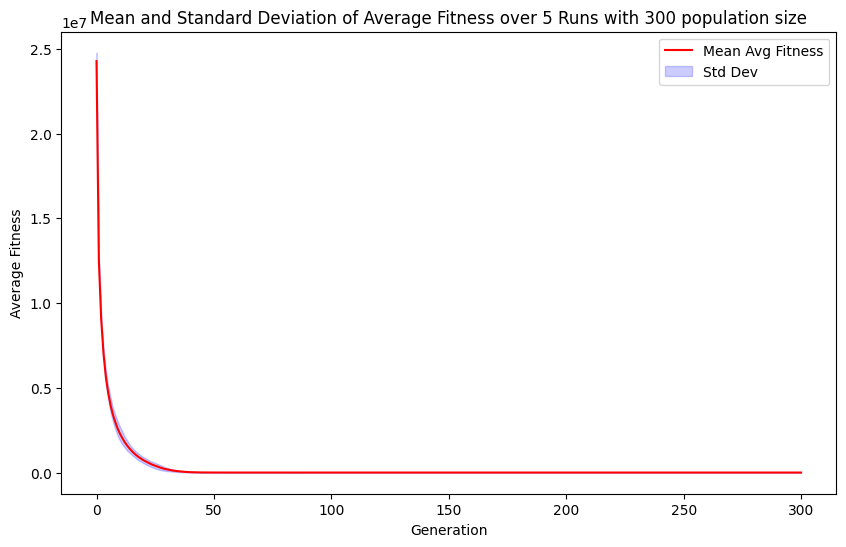

population size: 200
	Best fitness: 48082.5
			Generation: 71
	Best fitness: 1682.5
			Generation: 48
	Best fitness: 48082.5
			Generation: 68
	Best fitness: 48082.5
			Generation: 56
	Best fitness: 25982.5
			Generation: 109


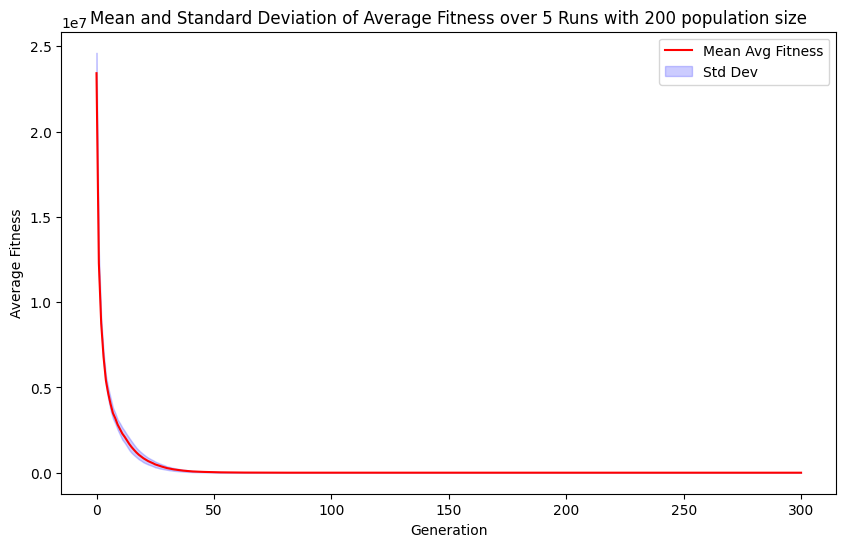

population size: 100
	Best fitness: 62.5
			Generation: 30
	Best fitness: 25982.5
			Generation: 275
	Best fitness: 25982.5
			Generation: 53
	Best fitness: 382.5
			Generation: 41
	Best fitness: 48082.5
			Generation: 66


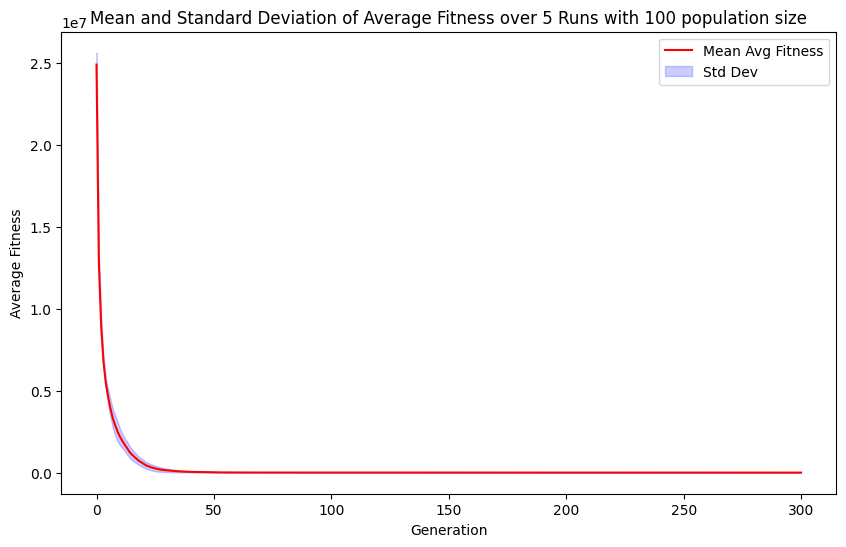

population size: 50
	Best fitness: 48082.5
			Generation: 37
	Best fitness: 382.5
			Generation: 41
	Best fitness: 5182.5
			Generation: 46
	Best fitness: 25982.5
			Generation: 34
	Best fitness: 48082.5
			Generation: 39


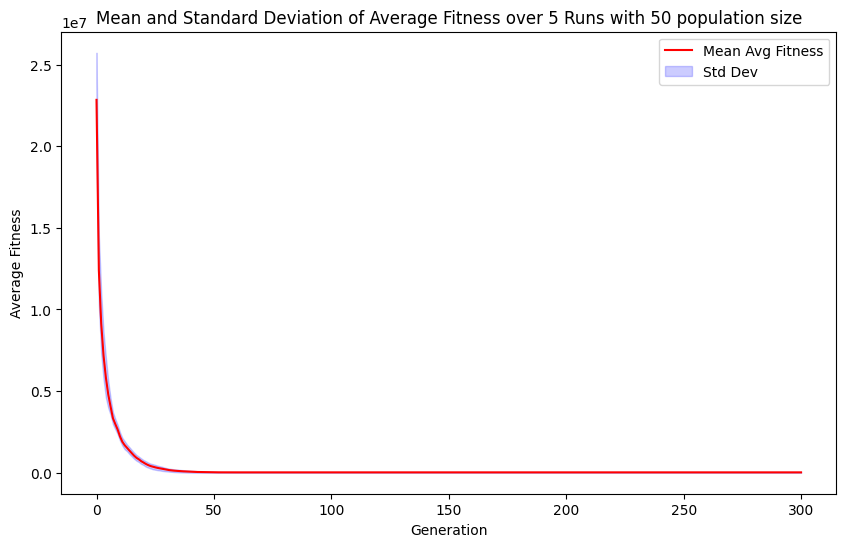

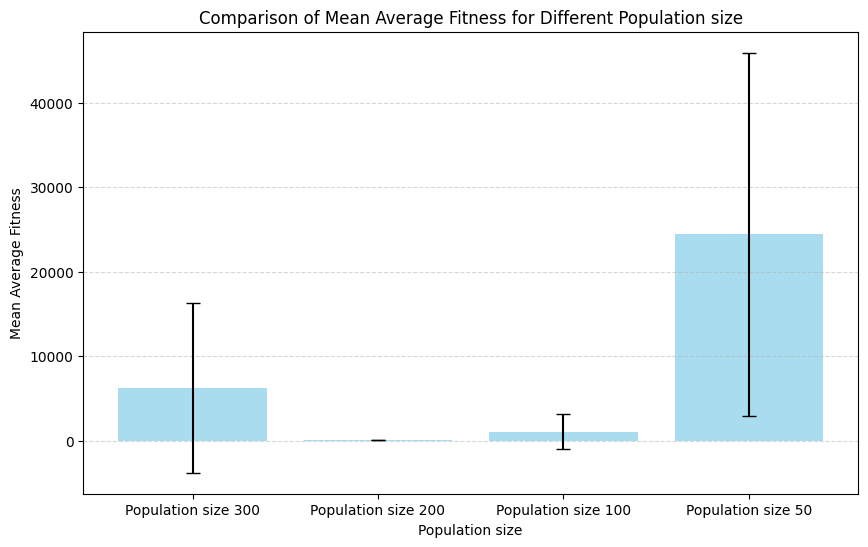

In [9]:
pop_sizes = [300, 200, 100, 50]
all_mean_avg_fitness = []
all_std_avg_fitness = []

for pop_size in pop_sizes:
    print("population size:",pop_size)
    fitness_values = []
    for _ in range(num_runs):
        bf, _, avg_fitness_values,_,bestgen,_ = genetic_coloring(file_path,pop_size,5,0.9,0.1,max_generations)
        avg_fitness_values = np.pad(avg_fitness_values, (0, max_generations+1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
        fitness_values.append(avg_fitness_values)
        print("\tBest fitness:",bf[best_gen])
        print("\t\t\tGeneration:",bestgen)
        
    fitness_values = np.array(fitness_values)
    mean_avg_fitness = np.mean(fitness_values, axis=0)
    std_avg_fitness = np.std(fitness_values, axis=0)
    generations = np.arange(len(mean_avg_fitness))
    plt.figure(figsize=(10, 6))
    plt.plot(generations, mean_avg_fitness, label='Mean Avg Fitness', color='red')
    plt.fill_between(generations, mean_avg_fitness - std_avg_fitness, mean_avg_fitness + std_avg_fitness, color='b', alpha=0.2, label='Std Dev')
    plt.xlabel('Generation')
    plt.ylabel('Average Fitness')
    plt.title(f'Mean and Standard Deviation of Average Fitness over 5 Runs with {pop_size} population size')
    plt.legend()
    plt.show()
    all_mean_avg_fitness.append(mean_avg_fitness[-1])
    all_std_avg_fitness.append(std_avg_fitness[-1])

plt.figure(figsize=(10, 6))
x = np.arange(len(pop_sizes))
plt.bar(x, all_mean_avg_fitness, yerr=all_std_avg_fitness, capsize=5, alpha=0.7, color='skyblue')

plt.xticks(x, [f'Population size {p}' for p in pop_sizes])
plt.xlabel('Population size')
plt.ylabel('Mean Average Fitness')
plt.title('Comparison of Mean Average Fitness for Different Population size')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


Crossover Prob 1
	Best fitness: 382.5
			Generation: 40
	Best fitness: 25982.5
			Generation: 74
	Best fitness: 25982.5
			Generation: 68
	Best fitness: 25982.5
			Generation: 52
	Best fitness: 25982.5
			Generation: 58


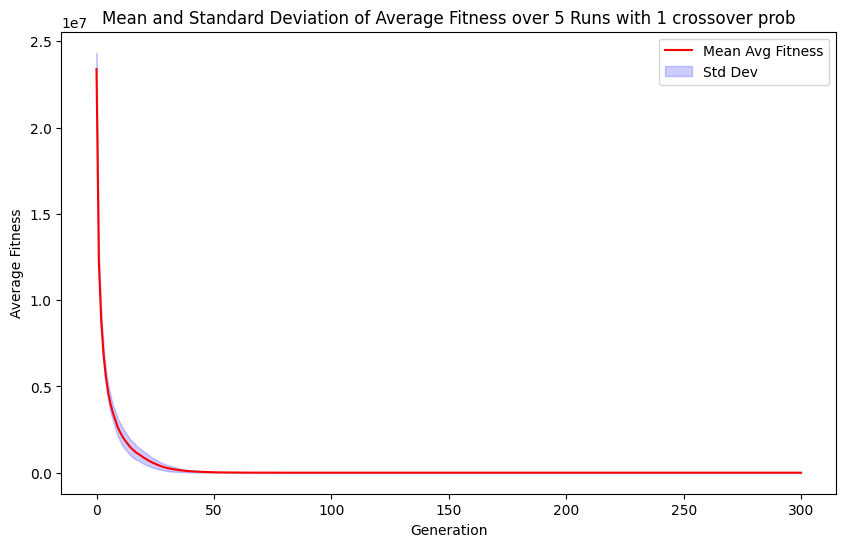

Crossover Prob 0.9
	Best fitness: 5182.5
			Generation: 48
	Best fitness: 12562.5
			Generation: 51
	Best fitness: 12562.5
			Generation: 224
	Best fitness: 81982.5
			Generation: 66
	Best fitness: 382.5
			Generation: 40


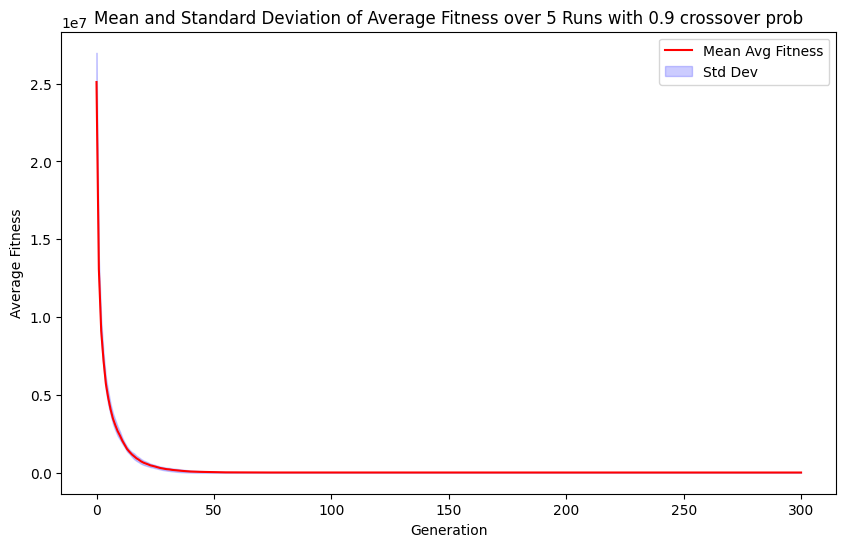

Crossover Prob 0.7
	Best fitness: 81982.5
			Generation: 273
	Best fitness: 25982.5
			Generation: 55
	Best fitness: 12562.5
			Generation: 41
	Best fitness: 81982.5
			Generation: 54
	Best fitness: 48082.5
			Generation: 253


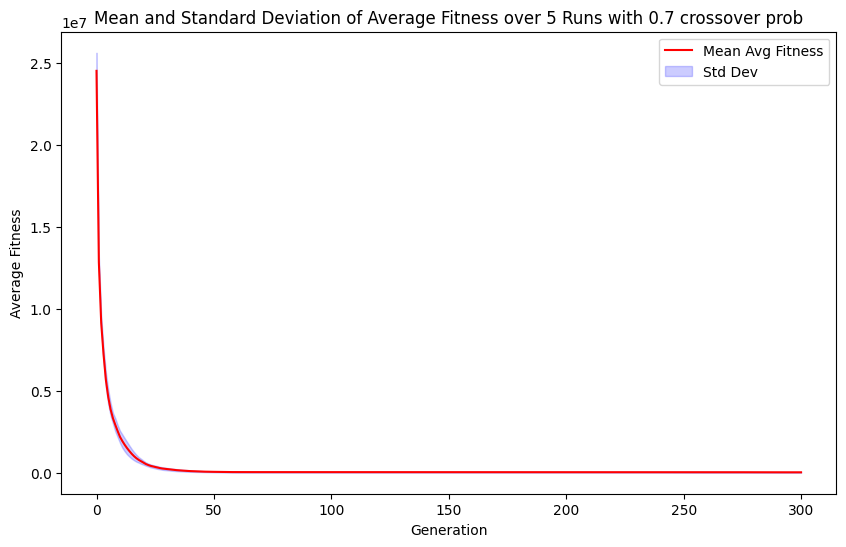

Crossover Prob 0.5
	Best fitness: 382.5
			Generation: 45
	Best fitness: 12562.5
			Generation: 45
	Best fitness: 12562.5
			Generation: 53
	Best fitness: 12562.5
			Generation: 64
	Best fitness: 25982.5
			Generation: 60


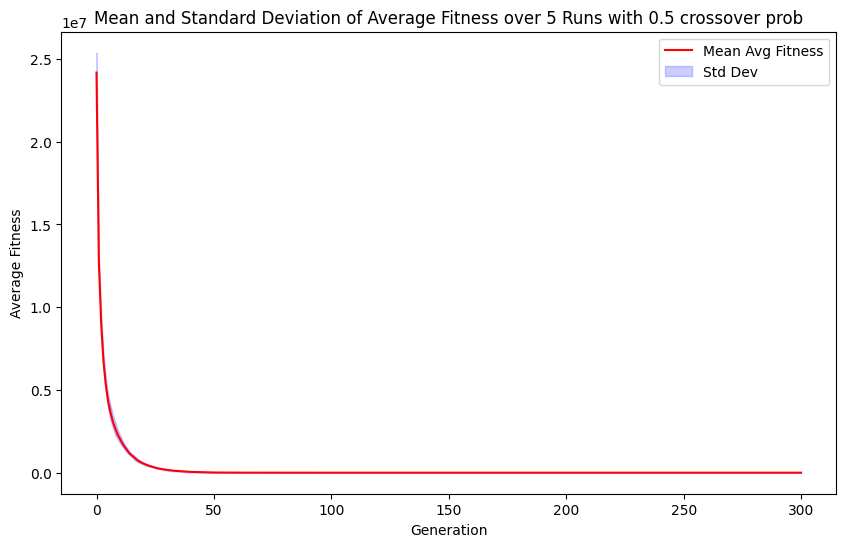

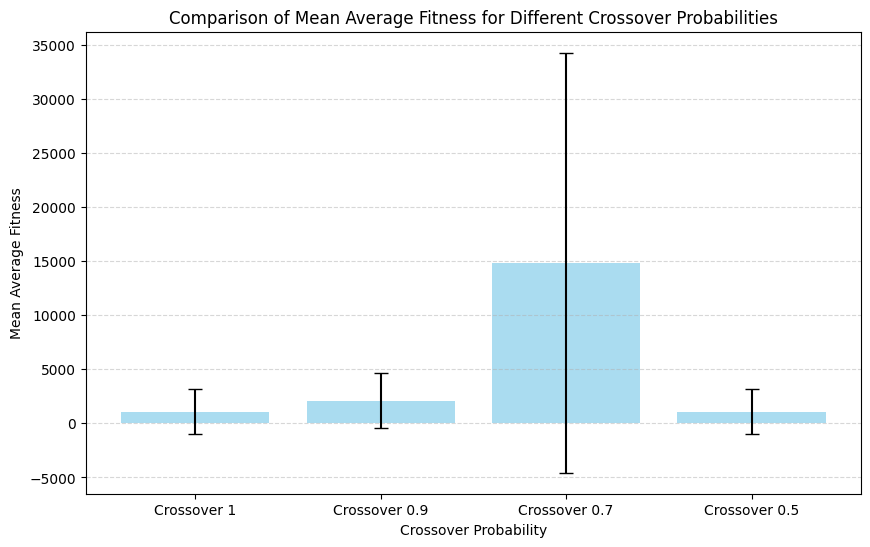

In [11]:
crossover_probs = [1, 0.9, 0.7, 0.5] 
all_mean_avg_fitness = []
all_std_avg_fitness = []

for crossover_prob in crossover_probs:
    print("Crossover Prob",crossover_prob)
    fitness_values = []
    for _ in range(num_runs):
        bf, _, avg_fitness_values,_,bestgen,_ = genetic_coloring(file_path,100,5,crossover_prob,0.1,max_generations)
        avg_fitness_values = np.pad(avg_fitness_values, (0, max_generations +1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
        fitness_values.append(avg_fitness_values)
        print("\tBest fitness:",bf[best_gen])
        print("\t\t\tGeneration:",bestgen)
        
    fitness_values = np.array(fitness_values)
    mean_avg_fitness = np.mean(fitness_values, axis=0)
    std_avg_fitness = np.std(fitness_values, axis=0)
    generations = np.arange(len(mean_avg_fitness))
    plt.figure(figsize=(10, 6))
    plt.plot(generations, mean_avg_fitness, label='Mean Avg Fitness', color='red')
    plt.fill_between(generations, mean_avg_fitness - std_avg_fitness, mean_avg_fitness + std_avg_fitness, color='b', alpha=0.2, label='Std Dev')
    plt.xlabel('Generation')
    plt.ylabel('Average Fitness')
    plt.title(f'Mean and Standard Deviation of Average Fitness over 5 Runs with {crossover_prob} crossover prob')
    plt.legend()
    plt.show()
    all_mean_avg_fitness.append(mean_avg_fitness[-1])
    all_std_avg_fitness.append(std_avg_fitness[-1])

plt.figure(figsize=(10, 6))
x = np.arange(len(crossover_probs))
plt.bar(x, all_mean_avg_fitness, yerr=all_std_avg_fitness, capsize=5, alpha=0.7, color='skyblue')

plt.xticks(x, [f'Crossover {p}' for p in crossover_probs])
plt.xlabel('Crossover Probability')
plt.ylabel('Mean Average Fitness')
plt.title('Comparison of Mean Average Fitness for Different Crossover Probabilities')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


mutation prob: 0.5
	Best fitness: 1012562.5
			Generation: 153
	Best fitness: 768382.5
			Generation: 49
	Best fitness: 768382.5
			Generation: 173
	Best fitness: 1310782.5
			Generation: 77
	Best fitness: 768382.5
			Generation: 289


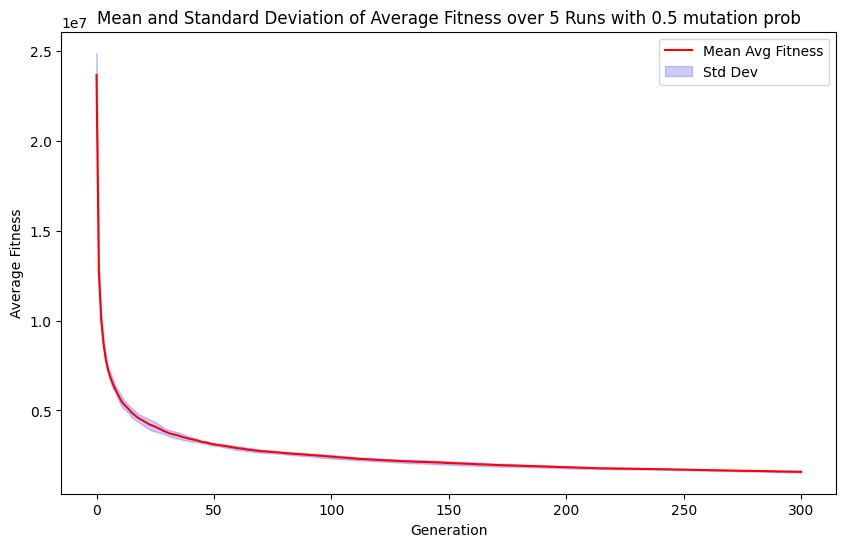

mutation prob: 0.3
	Best fitness: 571282.5
			Generation: 258
	Best fitness: 768382.5
			Generation: 289
	Best fitness: 292882.5
			Generation: 258
	Best fitness: 768382.5
			Generation: 275
	Best fitness: 768382.5
			Generation: 274


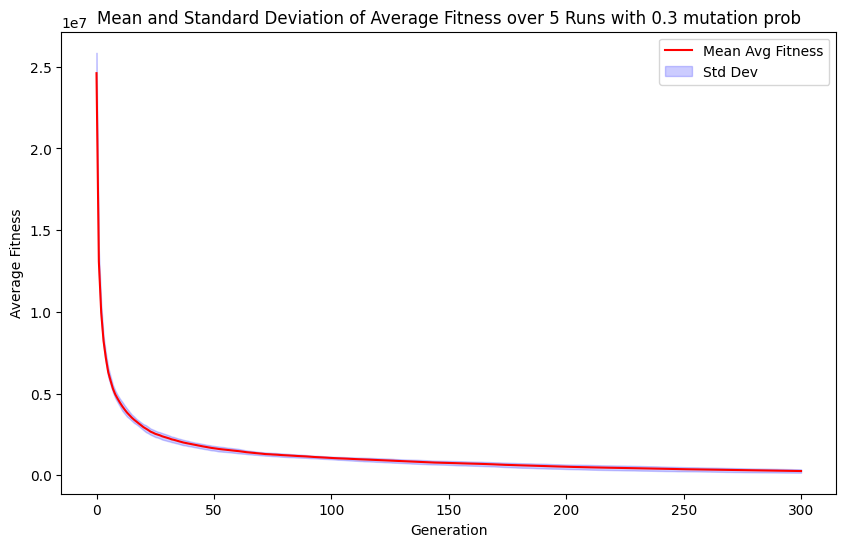

mutation prob: 0.1
	Best fitness: 25982.5
			Generation: 59
	Best fitness: 81982.5
			Generation: 97
	Best fitness: 1682.5
			Generation: 44
	Best fitness: 12562.5
			Generation: 55
	Best fitness: 25982.5
			Generation: 275


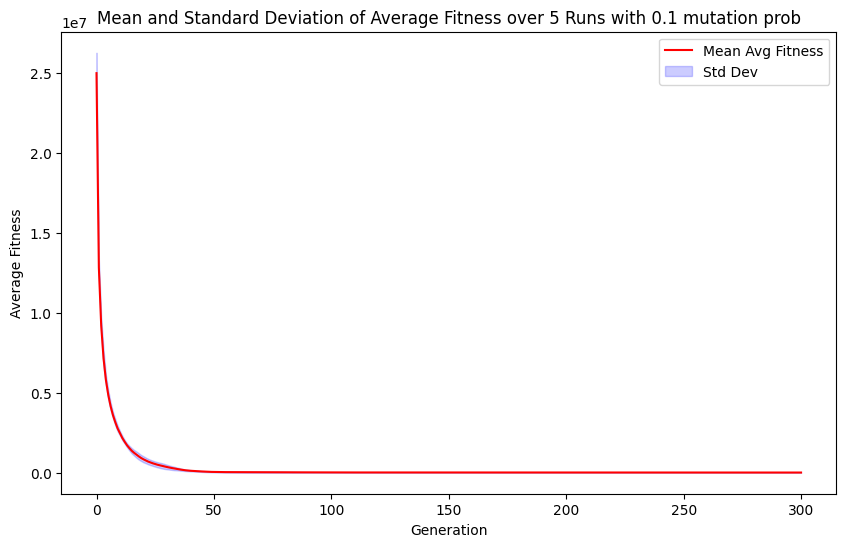

mutation prob: 0.05
	Best fitness: 62.5
			Generation: 32
	Best fitness: 62.5
			Generation: 38
	Best fitness: 48082.5
			Generation: 44
	Best fitness: 62.5
			Generation: 24
	Best fitness: 25982.5
			Generation: 130


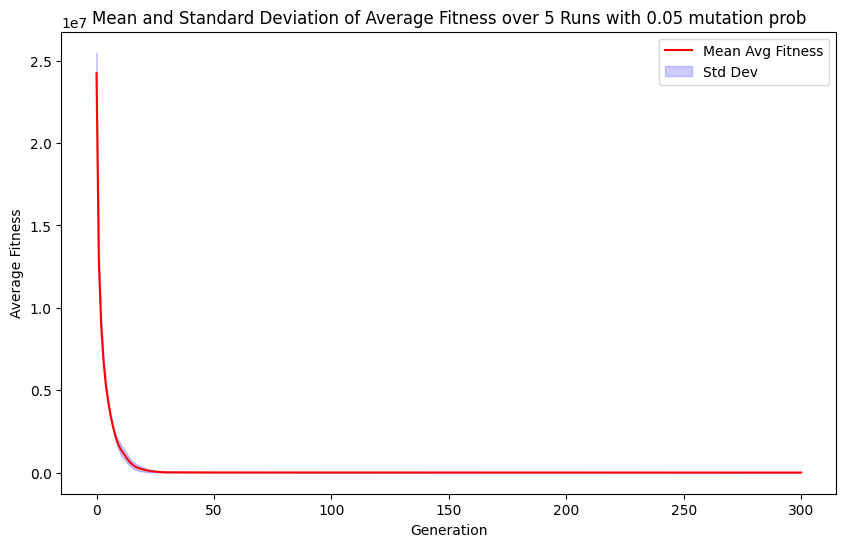

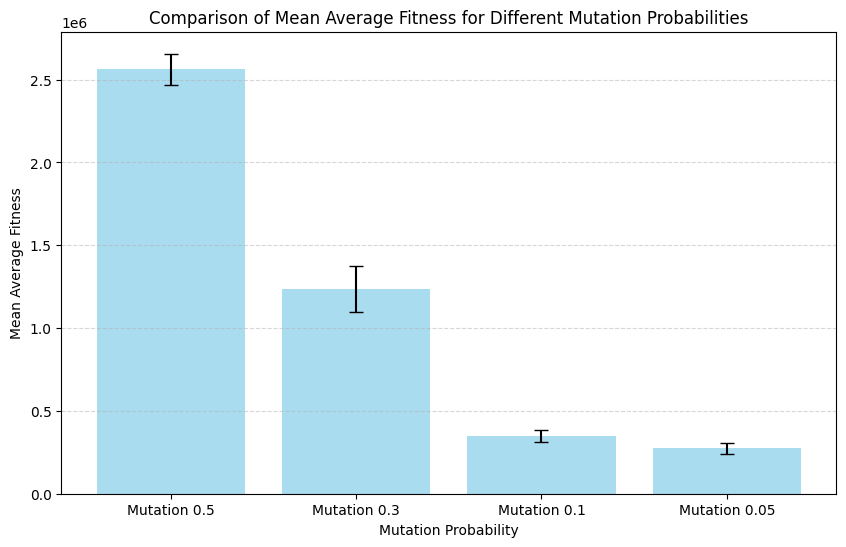

In [12]:
mutation_probs = [0.5 ,0.3 ,0.1, 0.05]
all_mean_avg_fitness = []
all_std_avg_fitness = []

for mutation_prob in mutation_probs:
    print("mutation prob:",mutation_prob)
    fitness_values = []
    for _ in range(num_runs):
        bf, _, avg_fitness_values,_,bestgen,_ = genetic_coloring(file_path,200,5,0.9,mutation_prob,max_generations)
        avg_fitness_values = np.pad(avg_fitness_values, (0, max_generations + 1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
        fitness_values.append(avg_fitness_values)
        print("\tBest fitness:",bf[best_gen])
        print("\t\t\tGeneration:",bestgen)
        
    fitness_values = np.array(fitness_values)
    mean_avg_fitness = np.mean(fitness_values, axis=0)
    std_avg_fitness = np.std(fitness_values, axis=0)
    generations = np.arange(len(mean_avg_fitness))
    plt.figure(figsize=(10, 6))
    plt.plot(generations, mean_avg_fitness, label='Mean Avg Fitness', color='red')
    plt.fill_between(generations, mean_avg_fitness - std_avg_fitness, mean_avg_fitness + std_avg_fitness, color='b', alpha=0.2, label='Std Dev')
    plt.xlabel('Generation')
    plt.ylabel('Average Fitness')
    plt.title(f'Mean and Standard Deviation of Average Fitness over 5 Runs with {mutation_prob} mutation prob')
    plt.legend()
    plt.show()

    fitness_values = np.array(fitness_values)
    mean_avg_fitness = np.mean(fitness_values, axis=0)
    std_avg_fitness = np.std(fitness_values, axis=0)
    
    all_mean_avg_fitness.append(np.nanmean(mean_avg_fitness))
    all_std_avg_fitness.append(np.nanmean(std_avg_fitness))

plt.figure(figsize=(10, 6))
x = np.arange(len(mutation_probs))
plt.bar(x, all_mean_avg_fitness, yerr=all_std_avg_fitness, capsize=5, alpha=0.7, color='skyblue')

plt.xticks(x, [f'Mutation {p}' for p in mutation_probs])
plt.xlabel('Mutation Probability')
plt.ylabel('Mean Average Fitness')
plt.title('Comparison of Mean Average Fitness for Different Mutation Probabilities')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

62.5 113
25982.5 59
62.5 83
25982.5 22
48082.5 24


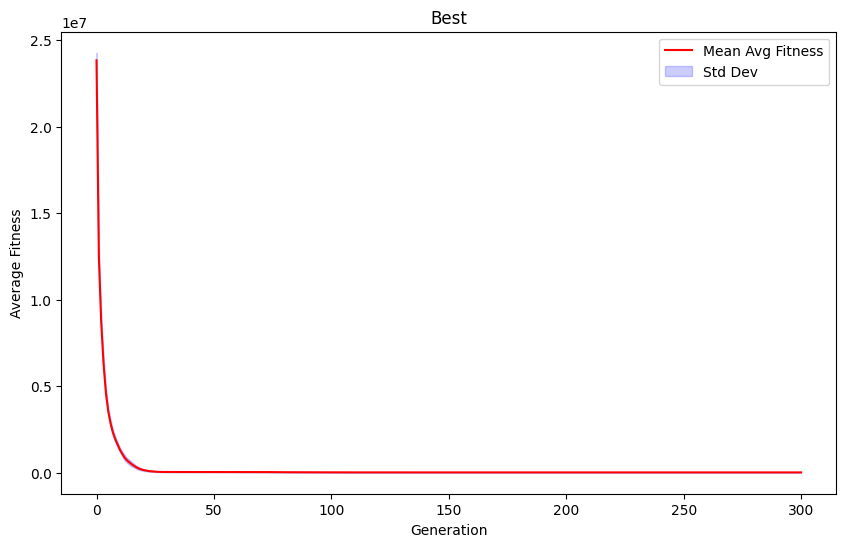

In [14]:
fitness_values = []
num_runs=5
max_generations=300
for _ in range(num_runs):
    bf, _, avg_fitness_values,_,bestgen,_ = genetic_coloring(file_path,200,5,0.5,0.05,max_generations)
    avg_fitness_values = np.pad(avg_fitness_values, (0, max_generations + 1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
    fitness_values.append(avg_fitness_values)
    print(bf[bestgen],bestgen)

fitness_values = np.array(fitness_values)
mean_avg_fitness = np.mean(fitness_values, axis=0)
std_avg_fitness = np.std(fitness_values, axis=0)

generations = np.arange(len(mean_avg_fitness))
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_avg_fitness, label='Mean Avg Fitness', color='red')
plt.fill_between(generations, mean_avg_fitness - std_avg_fitness, mean_avg_fitness + std_avg_fitness, color='b', alpha=0.2, label='Std Dev')
plt.xlabel('Generation')
plt.ylabel('Average Fitness')
plt.title('Best')
plt.legend()
plt.show()


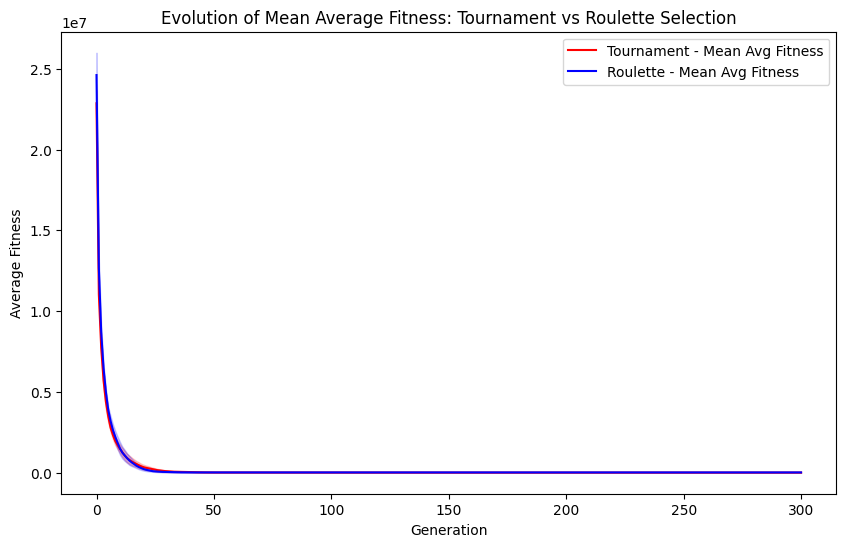

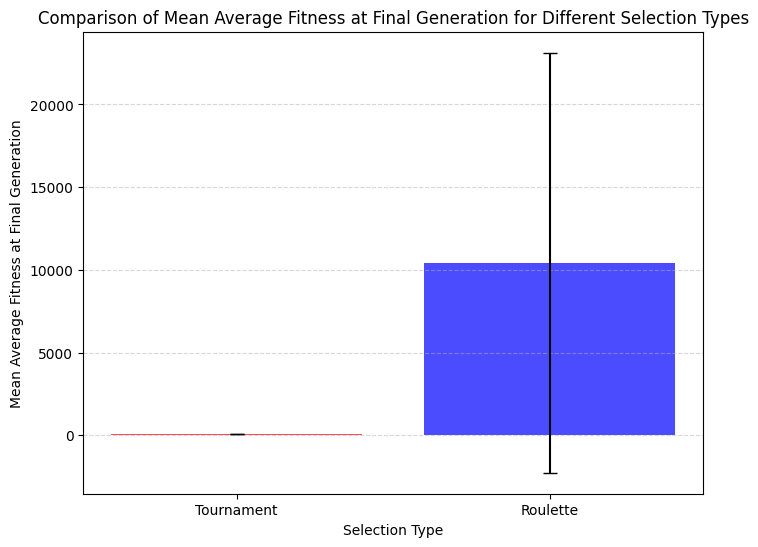

In [15]:
fitness_values_tournament = []
fitness_values_roulette = []
num_runs = 5
max_generations = 300

for _ in range(num_runs):
    bf, _, avg_fitness_values, _, bestgen, _ = genetic_coloring(file_path, 200, 5, 0.5, 0.05, max_generations, selection_type='Tournament')
    avg_fitness_values = np.pad(avg_fitness_values, (0, max_generations + 1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
    fitness_values_tournament.append(avg_fitness_values)

for _ in range(num_runs):
    bf, _, avg_fitness_values, _, bestgen, _ = genetic_coloring(file_path, 200, 5, 0.5, 0.05, max_generations, selection_type='Roulette')
    avg_fitness_values = np.pad(avg_fitness_values, (0, max_generations + 1 - len(avg_fitness_values)), 'constant', constant_values=np.nan)
    fitness_values_roulette.append(avg_fitness_values)

fitness_values_tournament = np.array(fitness_values_tournament)
fitness_values_roulette = np.array(fitness_values_roulette)

mean_avg_fitness_tournament = np.mean(fitness_values_tournament, axis=0)
std_avg_fitness_tournament = np.std(fitness_values_tournament, axis=0)

mean_avg_fitness_roulette = np.mean(fitness_values_roulette, axis=0)
std_avg_fitness_roulette = np.std(fitness_values_roulette, axis=0)

generations = np.arange(len(mean_avg_fitness_tournament))
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_avg_fitness_tournament, label='Tournament - Mean Avg Fitness', color='red')
plt.fill_between(generations, mean_avg_fitness_tournament - std_avg_fitness_tournament, mean_avg_fitness_tournament + std_avg_fitness_tournament, color='red', alpha=0.2)

plt.plot(generations, mean_avg_fitness_roulette, label='Roulette - Mean Avg Fitness', color='blue')
plt.fill_between(generations, mean_avg_fitness_roulette - std_avg_fitness_roulette, mean_avg_fitness_roulette + std_avg_fitness_roulette, color='blue', alpha=0.2)

plt.xlabel('Generation')
plt.ylabel('Average Fitness')
plt.title('Evolution of Mean Average Fitness: Tournament vs Roulette Selection')
plt.legend()
plt.show()

final_mean_avg_fitness = [mean_avg_fitness_tournament[-1], mean_avg_fitness_roulette[-1]]
final_std_avg_fitness = [std_avg_fitness_tournament[-1], std_avg_fitness_roulette[-1]]

plt.figure(figsize=(8, 6))
x = np.arange(2)
plt.bar(x, final_mean_avg_fitness, yerr=final_std_avg_fitness, capsize=5, alpha=0.7, color=['red', 'blue'])
plt.xticks(x, ['Tournament', 'Roulette'])
plt.xlabel('Selection Type')
plt.ylabel('Mean Average Fitness at Final Generation')
plt.title('Comparison of Mean Average Fitness at Final Generation for Different Selection Types')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


